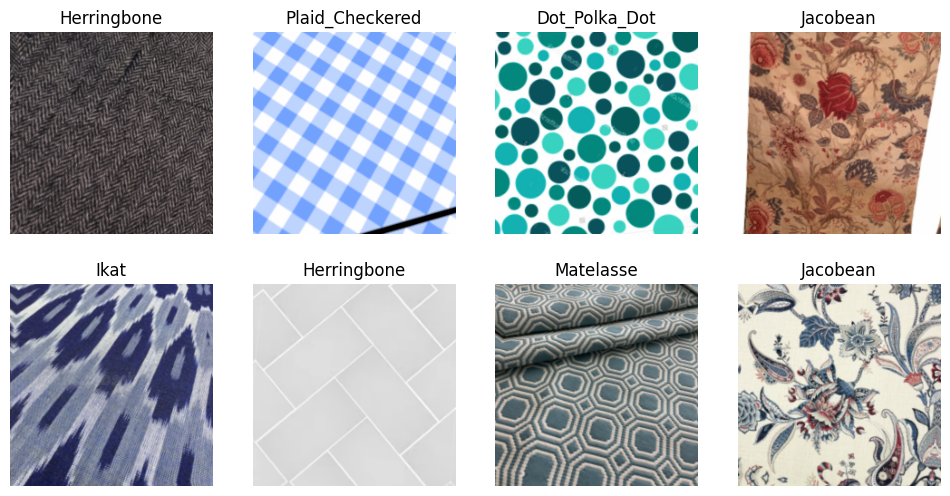

In [1]:
from fastai.vision.all import *
from collections import Counter
from pathlib import Path
import numpy as np

path = Path("/kaggle/input/textile-pattern")

dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(
        do_flip=True,
        max_rotate=15,
        max_zoom=1.1,
        max_lighting=0.2,
        max_warp=0.1
    )
)

# Build datasets once
dsets = dblock.datasets(path)

# Full item list in the same order used by the DataBlock
all_items = dsets.items

# Training indices from the split
train_idx = dsets.splits[0]

# Training items only
train_items = [all_items[i] for i in train_idx]
train_labels = [parent_label(o) for o in train_items]

# Compute class counts from training set only
counts = Counter(train_labels)

# Inverse-frequency class weights
class_to_weight = {cls: 1.0 / count for cls, count in counts.items()}

# Build FULL-LENGTH weights array
# fastai will internally take only the training part
wgts_full = np.array([class_to_weight.get(parent_label(o), 1.0) for o in all_items])

# Create weighted dataloaders
dls = dblock.weighted_dataloaders(
    path,
    wgts=wgts_full,
    bs=32
)

dls.show_batch(max_n=8)

In [2]:
# 2) Define candidate models to benchmark
architectures = {
    "resnet18": resnet18,
    "resnet34": resnet34,
    "resnet50": resnet50,
}

results = {}
learners = {}

In [3]:
from torchvision.models import resnet18, resnet34, resnet50
from fastai.callback.tracker import SaveModelCallback

architectures = {
    "resnet18": resnet18,
    "resnet34": resnet34,
    "resnet50": resnet50,
}

results = {}
learners = {}

for name, arch in architectures.items():
    print(f"\nTraining {name} ...")

    learn = vision_learner(
        dls,
        arch,
        metrics=[accuracy, error_rate]
    )

    # Disable notebook progress bar to avoid NBMasterBar error
    with learn.no_bar():
        learn.fine_tune(
            5,
            cbs=[SaveModelCallback(monitor='accuracy', fname=f'best_{name}')]
        )

    val_loss, acc, err = learn.validate()

    results[name] = {
        "valid_loss": float(val_loss),
        "accuracy": float(acc),
        "error_rate": float(err),
    }
    learners[name] = learn

print(results)


Training resnet18 ...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 223MB/s]


[0, 2.153029203414917, 1.2703819274902344, 0.6401180028915405, 0.3598819971084595, '00:57']
Better model found at epoch 0 with accuracy value: 0.6401180028915405.
[0, 1.1115375757217407, 0.9851093292236328, 0.7315634489059448, 0.26843658089637756, '00:55']
Better model found at epoch 0 with accuracy value: 0.7315634489059448.
[1, 0.8674192428588867, 0.885137677192688, 0.7595870494842529, 0.24041298031806946, '00:57']
Better model found at epoch 1 with accuracy value: 0.7595870494842529.
[2, 0.6196943521499634, 0.8818092942237854, 0.7743362784385681, 0.22566372156143188, '00:56']
Better model found at epoch 2 with accuracy value: 0.7743362784385681.
[3, 0.4734809994697571, 0.8417967557907104, 0.7861356735229492, 0.2138643115758896, '01:00']
Better model found at epoch 3 with accuracy value: 0.7861356735229492.
[4, 0.42368242144584656, 0.7996049523353577, 0.8008849620819092, 0.19911503791809082, '00:58']
Better model found at epoch 4 with accuracy value: 0.8008849620819092.



Training resnet34 ...
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 169MB/s]


[0, 2.1006715297698975, 1.1921114921569824, 0.6563422083854675, 0.34365782141685486, '00:57']
Better model found at epoch 0 with accuracy value: 0.6563422083854675.
[0, 1.0490777492523193, 0.9086111783981323, 0.7418879270553589, 0.2581121027469635, '00:59']
Better model found at epoch 0 with accuracy value: 0.7418879270553589.
[1, 0.8107932209968567, 0.9271974563598633, 0.7492625117301941, 0.2507374584674835, '00:58']
Better model found at epoch 1 with accuracy value: 0.7492625117301941.
[2, 0.6121429800987244, 0.8153656125068665, 0.7846607565879822, 0.21533922851085663, '00:59']
Better model found at epoch 2 with accuracy value: 0.7846607565879822.
[3, 0.4574892818927765, 0.8008239269256592, 0.7935103178024292, 0.2064896821975708, '00:57']
Better model found at epoch 3 with accuracy value: 0.7935103178024292.
[4, 0.33355337381362915, 0.7806664109230042, 0.7935103178024292, 0.2064896821975708, '00:56']



Training resnet50 ...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


[0, 1.817571997642517, 1.1402922868728638, 0.6799409985542297, 0.32005900144577026, '01:01']
Better model found at epoch 0 with accuracy value: 0.6799409985542297.
[0, 0.9015579223632812, 0.8818349242210388, 0.73893803358078, 0.2610619366168976, '00:59']
Better model found at epoch 0 with accuracy value: 0.73893803358078.
[1, 0.6759010553359985, 0.8182739615440369, 0.7817109227180481, 0.2182890921831131, '00:59']
Better model found at epoch 1 with accuracy value: 0.7817109227180481.
[2, 0.5573171973228455, 0.7913139462471008, 0.7890855669975281, 0.21091444790363312, '01:01']
Better model found at epoch 2 with accuracy value: 0.7890855669975281.
[3, 0.44479095935821533, 0.7031376957893372, 0.8067846894264221, 0.19321534037590027, '01:00']
Better model found at epoch 3 with accuracy value: 0.8067846894264221.
[4, 0.33836013078689575, 0.6985034942626953, 0.8112094402313232, 0.18879055976867676, '01:00']
Better model found at epoch 4 with accuracy value: 0.8112094402313232.


{'resnet18': {'valid_loss': 0.7996049523353577, 'accuracy': 0.8008849620819092, 'error_rate': 0.19911503791809082}, 'resnet34': {'valid_loss': 0.8008239269256592, 'accuracy': 0.7935103178024292, 'error_rate': 0.2064896821975708}, 'resnet50': {'valid_loss': 0.6985034942626953, 'accuracy': 0.8112094402313232, 'error_rate': 0.18879055976867676}}


Best model = resnet50
{'valid_loss': 0.6985034942626953, 'accuracy': 0.8112094402313232, 'error_rate': 0.18879055976867676}


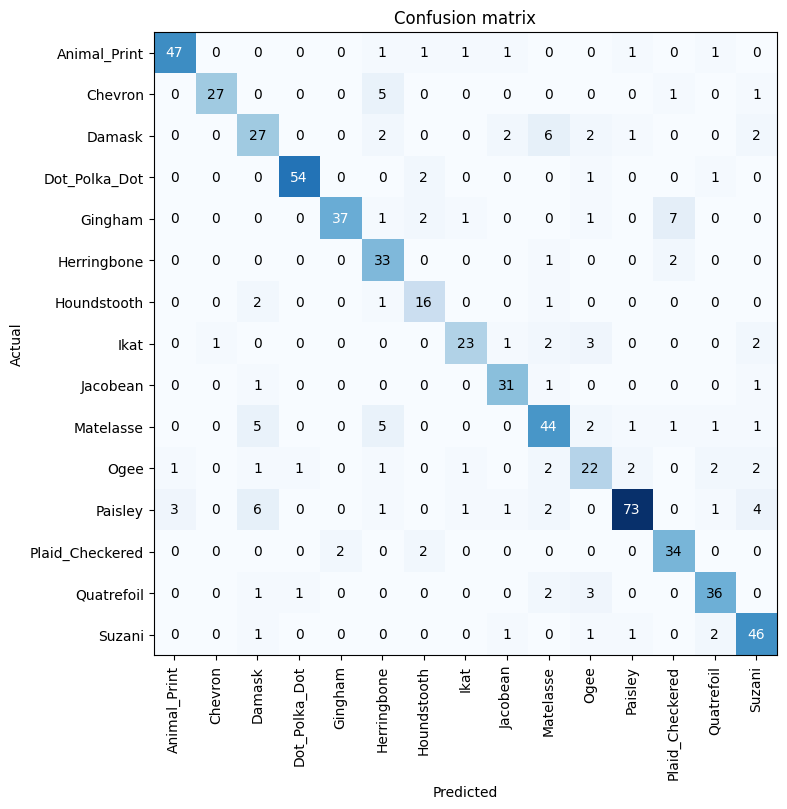

In [4]:
best_name = max(results, key=lambda x: results[x]["accuracy"])
best_learn = learners[best_name]

print("Best model =", best_name)
print(results[best_name])

interp = ClassificationInterpretation.from_learner(best_learn)
interp.plot_confusion_matrix(figsize=(8, 8), dpi=100)

In [5]:
best_learn.load(f'best_{best_name}')

with best_learn.no_bar():
    best_learn.unfreeze()
    best_learn.fit_one_cycle(
        10,
        lr_max=slice(1e-6, 1e-4),
        cbs=[SaveModelCallback(monitor='accuracy', fname=f'final_{best_name}')]
    )

best_learn.load(f'final_{best_name}')
best_learn.export("textile_pattern_best.pkl")

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


[0, 0.3580770790576935, 0.6950327754020691, 0.8082596063613892, 0.19174040853977203, '01:01']
Better model found at epoch 0 with accuracy value: 0.8082596063613892.
[1, 0.3409103453159332, 0.6755883097648621, 0.8053097128868103, 0.1946902722120285, '01:01']
[2, 0.27751705050468445, 0.7273358702659607, 0.8038347959518433, 0.19616518914699554, '01:01']
[3, 0.2700660824775696, 0.7023894190788269, 0.8038347959518433, 0.19616518914699554, '00:59']
[4, 0.2507658004760742, 0.6954848766326904, 0.8156341910362244, 0.18436577916145325, '01:00']
Better model found at epoch 4 with accuracy value: 0.8156341910362244.
[5, 0.22904755175113678, 0.679114580154419, 0.8082596063613892, 0.19174040853977203, '00:59']
[6, 0.2364468276500702, 0.6764489412307739, 0.8156341910362244, 0.18436577916145325, '01:02']
[7, 0.2406543791294098, 0.6585548520088196, 0.8112094402313232, 0.18879055976867676, '00:59']
[8, 0.23175013065338135, 0.6747264862060547, 0.8171091675758362, 0.1828908622264862, '00:58']
Better model